In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.06MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.14MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.95MB/s]


Trial 1/10, Test Accuracy: 0.9775
Trial 2/10, Test Accuracy: 0.9776
Trial 3/10, Test Accuracy: 0.9786
Trial 4/10, Test Accuracy: 0.9758
Trial 5/10, Test Accuracy: 0.9775
Trial 6/10, Test Accuracy: 0.9802
Trial 7/10, Test Accuracy: 0.9757
Trial 8/10, Test Accuracy: 0.9748
Trial 9/10, Test Accuracy: 0.9783
Trial 10/10, Test Accuracy: 0.9795

Average accuracy over 10 trials: 0.9775
Best accuracy: 0.9802


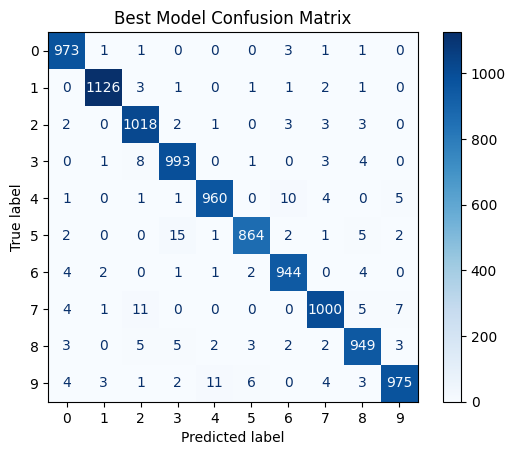

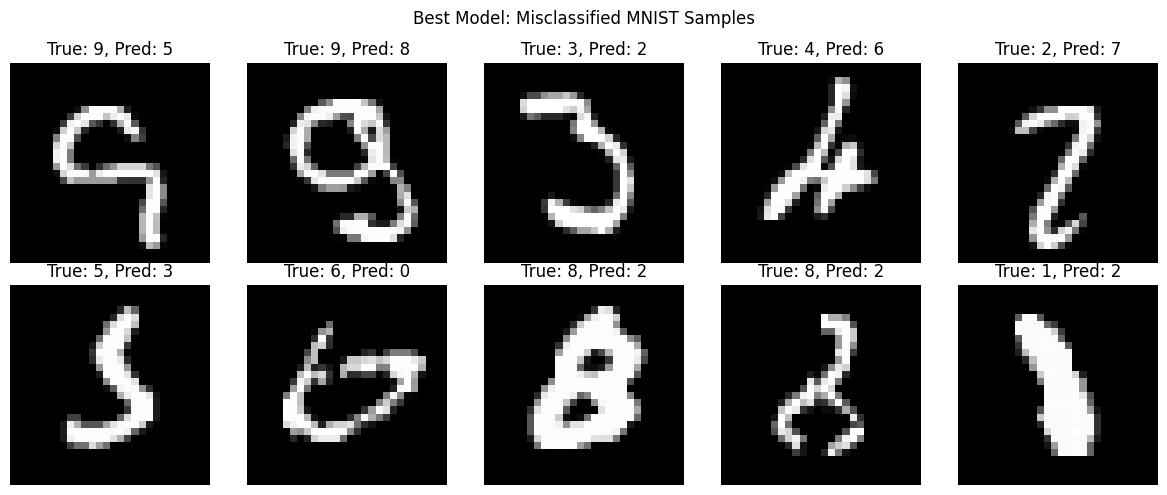

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
num_epochs = 5
batch_size = 64
learning_rate = 0.001
hidden1 = 256
hidden2 = 128
num_classes = 10
num_trials = 10

# MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

accuracies = []
best_acc = 0
best_state_dict = None
best_preds = None
best_labels = None
best_mis_images = []
best_mis_preds = []
best_mis_labels = []

for trial in range(num_trials):
    torch.manual_seed(trial)  # Different initialization each trial
    model = MLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    # Training
    for epoch in range(num_epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    preds = []
    labels_all = []
    mis_images = []
    mis_preds = []
    mis_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            preds.extend(predicted.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

            mask = predicted != labels
            if mask.any():
                mis_images.extend(images[mask].cpu())
                mis_preds.extend(predicted[mask].cpu().numpy())
                mis_labels.extend(labels[mask].cpu().numpy())

    acc = np.mean(np.array(preds) == np.array(labels_all))
    accuracies.append(acc)
    print(f'Trial {trial+1}/{num_trials}, Test Accuracy: {acc:.4f}')
    if acc > best_acc:
        best_acc = acc
        best_state_dict = model.state_dict()
        best_preds = preds
        best_labels = labels_all
        best_mis_images = mis_images
        best_mis_preds = mis_preds
        best_mis_labels = mis_labels

print(f'\nAverage accuracy over {num_trials} trials: {np.mean(accuracies):.4f}')
print(f'Best accuracy: {best_acc:.4f}')

# Plot confusion matrix for best model
cm = confusion_matrix(best_labels, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title("Best Model Confusion Matrix")
plt.show()

# Plot some misclassified samples from best model
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Best Model: Misclassified MNIST Samples')
for i, ax in enumerate(axes.flat):
    if i < len(best_mis_images):
        img = best_mis_images[i].squeeze().numpy()
        true_label = best_mis_labels[i]
        pred_label = best_mis_preds[i]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {true_label}, Pred: {pred_label}')
        ax.axis('off'
        )
plt.tight_layout()
plt.show()